<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-297-Natural-Language-Processing/blob/main/HW1_Word_Embeddings_and_OpenAI_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 — Word Embeddings & the OpenAI API

**Name:** Meenakshi Rajpurohit


This notebook contains my two required deliverables:

1. **Submission 1 — Word Embeddings Visualization.** I choose my own words, organize them into four groups, ask OpenAI for each word's *embedding* (a numeric vector representing its meaning), then plot the vectors in 2D so that similar words cluster together.
2. **Submission 2 — Chat API Call.** I make a call to an OpenAI chat model and display the assistant's response message.



## Step 1 — Install the required packages

Colab already includes `numpy`, `matplotlib`, and `scikit-learn`, but we install `openai` and `python-dotenv` (and re-list the others so this runs anywhere).

In [1]:
!pip install openai python-dotenv matplotlib scikit-learn numpy --quiet

## Step 2 — Set up your OpenAI API key (securely)

1. Get a key at **https://platform.openai.com/api-keys** (create the key, copy it once, and add a little billing credit — this whole assignment costs well under a cent).
2. **Never paste your real key directly into a code cell** that you'll share. Use one of the two secure methods below.

### Method A — `.env` file (what the assignment describes)
Create a file named exactly `.env` in your working directory containing one line:

```
OPENAI_API_KEY=sk-your-own-real-key-here
```

In **Colab**, the working directory is `/content`. You can create the `.env` by running the `%%writefile` cell below (replace the placeholder with your key). Note: because this writes the key into the notebook, clear that cell's output and don't commit the notebook publicly.

### Method B — Colab Secrets (recommended in Colab)
Click the **🔑 key icon** in the left sidebar → **Add new secret** → name it `OPENAI_API_KEY`, paste your key as the value, and toggle **Notebook access** on. Nothing sensitive ends up in the notebook this way.

The loader cell further down works with **either** method.

**(Method A helper — optional)** Run this only if you want to create a `.env` file. Replace the placeholder key with your real one first.

In [2]:
%%writefile .env
OPENAI_API_KEY=OPENAI_API_KEY

Writing .env


Now load the key. This tries the `.env` file first (and prints whether `load_dotenv()` found it, as the assignment asks), then falls back to Colab Secrets.

In [6]:
import os
from openai import OpenAI

api_key = None

# 1) Try Colab Secrets (the 🔑 panel) — this is what you set up
try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception as e:
    print("Colab Secrets not available/authorized:", e)

# 2) Fall back to a .env file if you used one instead
if not api_key:
    from dotenv import load_dotenv
    load_dotenv()
    api_key = os.environ.get("OPENAI_API_KEY")

# 3) Check it's a real key (they always start with "sk-")
if not api_key or not api_key.startswith("sk-"):
    raise ValueError(
        "The value found is not a real OpenAI key.\n"
        "Open the 🔑 Secrets panel, click OPENAI_API_KEY, and paste your ACTUAL key\n"
        "(it starts with 'sk-') into the VALUE box — not the text 'OPENAI_API_KEY'.\n"
        "Then re-run this cell."
    )

os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI()
print("Key loaded OK:", api_key[:6] + "..." + api_key[-4:])

Key loaded OK: sk-pro...65AA


## Step 3 — Create the OpenAI client

The client automatically reads `OPENAI_API_KEY` from the environment we just set.

In [7]:
from openai import OpenAI

client = OpenAI()
print("OpenAI client ready.")

OpenAI client ready.


---
## Submission 1 — Word Embeddings Visualization

An **embedding** converts a word into a long list of numbers (a vector, here 1536 numbers) that captures its meaning. Words with similar meanings get similar vectors.

My plan:
1. Define **four groups** of related words (my own choice).
2. Request an embedding for every word in a single batched API call.
3. The vectors have 1536 dimensions, so I use **PCA** to compress them to 2 dimensions.
4. Plot the 2D points, colored by group — related words should form visible clusters.

### Step 1 — Define my four word groups and fetch their embeddings

In [8]:
import numpy as np

# --- My own four groups of related words (edit these to make them yours) ---
word_groups = {
    "Fruits":    ["apple", "banana", "orange", "grape", "mango"],
    "Animals":   ["dog", "cat", "elephant", "lion", "tiger"],
    "Countries": ["France", "Japan", "Brazil", "Egypt", "Canada"],
    "Sports":    ["soccer", "basketball", "tennis", "swimming", "boxing"],
}

# Flatten into parallel lists: each word and the group it belongs to
words, labels = [], []
for group, items in word_groups.items():
    for w in items:
        words.append(w)
        labels.append(group)

# One batched call returns an embedding for every word, in order
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=words,
)
embeddings = np.array([item.embedding for item in response.data])

print("Number of words:", len(words))
print("Embedding shape:", embeddings.shape)   # (num_words, 1536)

Number of words: 20
Embedding shape: (20, 1536)


### Step 2 — Reduce to 2D with PCA and draw the scatter plot

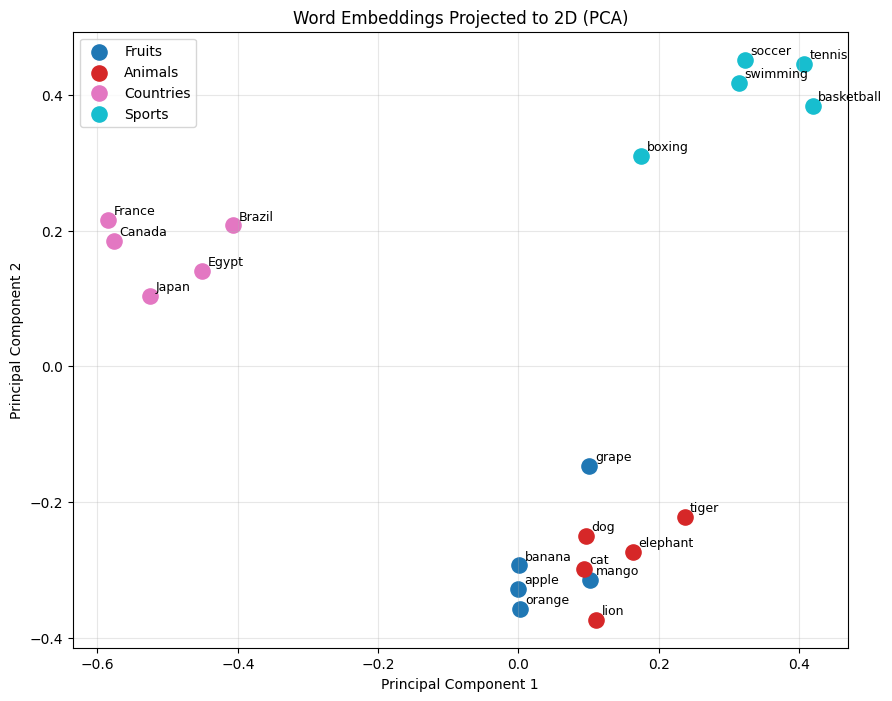

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Compress 1536-dim vectors down to 2 dimensions so we can plot them
coords = PCA(n_components=2).fit_transform(embeddings)

plt.figure(figsize=(10, 8))
group_names = list(word_groups.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(group_names)))

for i, group in enumerate(group_names):
    idx = [j for j, lbl in enumerate(labels) if lbl == group]
    plt.scatter(coords[idx, 0], coords[idx, 1],
                color=colors[i], label=group, s=120)
    for j in idx:
        plt.annotate(words[j], (coords[j, 0], coords[j, 1]),
                     fontsize=9, xytext=(4, 4), textcoords="offset points")

plt.title("Word Embeddings Projected to 2D (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### (Optional bonus) The classic *king − man + woman ≈ queen* relationship

Embeddings capture relationships, not just categories. Below, the arrow from **man → woman** and the arrow from **king → queen** point in a similar direction, showing the "gender" relationship is encoded consistently.

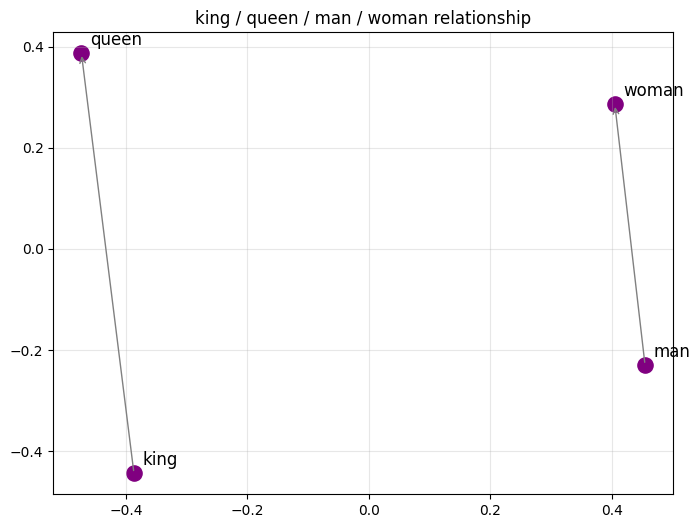

In [10]:
analogy_words = ["king", "queen", "man", "woman"]

emb = client.embeddings.create(
    model="text-embedding-3-small",
    input=analogy_words,
).data
vecs = np.array([e.embedding for e in emb])

pts = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], s=120, color="purple")
for w, (x, y) in zip(analogy_words, pts):
    plt.annotate(w, (x, y), fontsize=12, xytext=(6, 6), textcoords="offset points")

# Draw the two relationship arrows
d = dict(zip(analogy_words, pts))
plt.annotate("", xy=d["woman"], xytext=d["man"],
             arrowprops=dict(arrowstyle="->", color="gray"))
plt.annotate("", xy=d["queen"], xytext=d["king"],
             arrowprops=dict(arrowstyle="->", color="gray"))

plt.title("king / queen / man / woman relationship")
plt.grid(True, alpha=0.3)
plt.show()

---
## Submission 2 — Chat API Call

Here I call an OpenAI chat model with a short conversation and print the assistant's reply. You can replace the message contents with your own.

In [11]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system",    "content": "You are a helpful assistant."},
        {"role": "user",      "content": "Knock knock."},
        {"role": "assistant", "content": "Who is there?"},
        {"role": "user",      "content": "Michael"},
    ],
)

# The assistant's reply text lives here
print(response.choices[0].message.content)

Michael who?


---
## Notes

- **Models used:** `text-embedding-3-small` (embeddings) and `gpt-4o-mini` (chat) — both are inexpensive and appropriate here. If either ever returns a *"model not found"* error, check the current list at https://platform.openai.com/docs/models and substitute the name; the rest of the code is unchanged.
- Before exporting/submitting, run **Runtime ▸ Run all** so that both the scatter plot and the printed chat response appear as saved output in the notebook (the rubric grades on execution results).